In [5]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned.csv")

In [7]:
# Explicit column names
dance_col = "danceability_%"
energy_col = "energy_%"
valence_col = "valence_%"
tempo_col = "bpm"

In [8]:
# Convert to numeric
df[dance_col] = pd.to_numeric(df[dance_col], errors='coerce')
df[energy_col] = pd.to_numeric(df[energy_col], errors='coerce')
df[valence_col] = pd.to_numeric(df[valence_col], errors='coerce')
df[tempo_col] = pd.to_numeric(df[tempo_col], errors='coerce')

# Drop NaN
df = df.dropna(subset=[dance_col, energy_col, valence_col, tempo_col])

In [9]:
# Select features
X = df[[dance_col, energy_col, valence_col, tempo_col]]

In [10]:
# KMeans
kmeans = KMeans(n_clusters=3, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X)

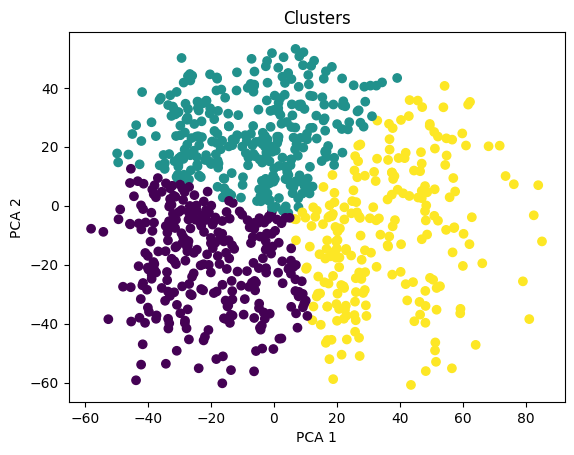

In [11]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_label'])
plt.title("Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [ ]:
# Save
df.to_csv("../data/clustered.csv", index=False)

The clustering results show that the songs can be divided into three main groups based on their musical characteristics. The first cluster represents energetic and danceable songs, which have high values of energy, danceability, and tempo. These songs are likely to be suitable for parties or active listening. The second cluster includes calmer tracks with lower energy and tempo, and often lower valence, meaning they may sound more relaxed or emotional. The third cluster represents a balanced group, with moderate values across most features, combining elements of both energetic and calm songs.

The separation between clusters is partially clear but not perfect. While some groups are visibly distinct in the PCA plot, there is still some overlap between clusters. This suggests that song characteristics exist on a spectrum rather than in strictly separate categories. As a result, the clustering captures general patterns, but the boundaries between groups are somewhat ambiguous.